In [15]:
# Import libraries
import pandas as pd

# Load dataset (upload in Colab first)
df = pd.read_csv('q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end (1 if day >= 25 else 0)
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
df.head()



,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [16]:
# Sort data by date
df = df.sort_values(by='transaction_date')

# Split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split data
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Separate features and target
X_train = train_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop('items_sold', axis=1)
y_test = test_df['items_sold']

# Check sizes
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (960, 12)
Test size: (240, 12)


### Interpretation:

A random split is not appropriate for time-ordered data because it can mix past and future observations between the training and test sets. This leads to data leakage, where the model indirectly learns from future information, resulting in overly optimistic performance.

In this case, the data is sorted by transaction_date, and the most recent 20% is used as the test set while the earlier 80% is used for training. This approach better reflects real-world scenarios, where models are trained on historical data and used to predict future outcomes.

From the output, we can see that the training set contains 960 records and the test set contains 240 records, maintaining the 80:20 split while preserving the time sequence of the data.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [
    'store_id', 'is_weekend', 'is_festival',
    'competition_density', 'year', 'month', 'day_of_week', 'is_month_end'
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)
# Apply preprocessing
X_train_transformed = preprocessor.fit_transform(X_train)

print("Transformed shape:", X_train_transformed.shape)


Transformed shape: (960, 16)


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# RMSE & MAE
print("Linear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("MAE:", mean_absolute_error(y_test, lr_pred))

print("\nRandom Forest:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE:", mean_absolute_error(y_test, rf_pred))



Linear Regression:
RMSE: 27.12145116489062
MAE: 21.052926674588388

Random Forest:
RMSE: 31.660007317329118
MAE: 24.87391666666667


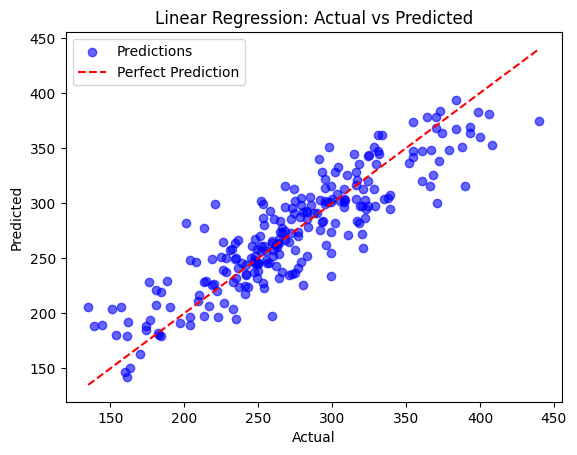

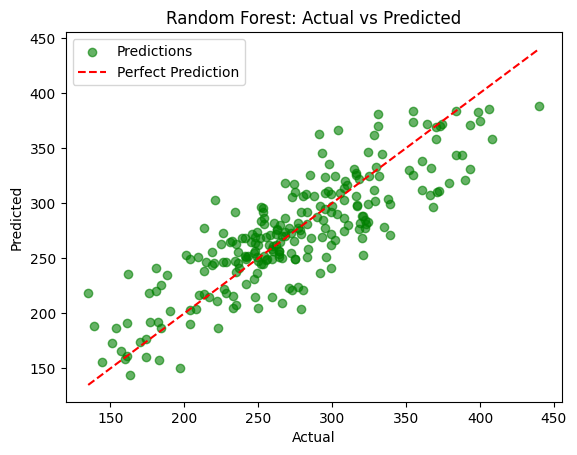

In [20]:
import matplotlib.pyplot as plt

# Linear Regression plot
plt.figure()

# Scatter points
plt.scatter(y_test, lr_pred, color='blue', alpha=0.6, label='Predictions')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()


# Random Forest plot
plt.figure()

# Scatter points
plt.scatter(y_test, rf_pred, color='green', alpha=0.6, label='Predictions')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()



In [21]:
# Get feature names after preprocessing
feature_names = (
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)) +
    numerical_cols
)

# Get feature importance
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Show top 5
print("Top 5 Features:")
feature_importance_df.head()


Top 5 Features:


,feature,importance
7,store_size_small,0.183954
10,is_festival,0.174477
5,location_type_urban,0.140498
14,day_of_week,0.090612
9,is_weekend,0.063547
